# Notebook 07 — Categorical Features: Does the Product Name Encode Price Level?

**Family**: Name-as-signal  
**Lens**: For each of the 10 product categories, parse the embedded feature (size, color, area, shape, flavor, etc.) and test whether it encodes mean mid-price.

**Method**:
- Compute mean mid-price per product per day (days 2, 3, 4).
- Assign an ordinal (or numeric) encoding to the parsed feature.
- Run OLS regression of mean mid vs. ordinal, report R².
- Compute Spearman ρ between feature rank and price rank.
- Repeat for all three days; note consistency.

**Data**: `data/round_5/prices/prices_round_5_day_{2,3,4}.csv` (semicolon-separated, read-only)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/bensinek/Documents/Coding/Prosperity4/data/round_5/prices'

days = [2, 3, 4]
dfs = []
for d in days:
    tmp = pd.read_csv(f'{BASE}/prices_round_5_day_{d}.csv', sep=';')
    tmp['day'] = d
    dfs.append(tmp)
df = pd.concat(dfs, ignore_index=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Products:', sorted(df['product'].unique()))

Shape: (1500000, 17)
Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']
Products: ['GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_FLAMES', 'GALAXY_SOUNDS_SOLAR_WINDS', 'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE', 'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_GARLIC', 'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_MORNING_BREATH', 'PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4', 'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS', 'ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING', 'SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE', 'S

## Cell 2 — Compute mean mid per product per day

In [2]:
# Mean mid-price per product per day
mean_mid = df.groupby(['day', 'product'])['mid_price'].mean().reset_index()
mean_mid.columns = ['day', 'product', 'mean_mid']

# Also overall mean across all days
overall_mean = df.groupby('product')['mid_price'].mean().reset_index()
overall_mean.columns = ['product', 'mean_mid_all']

print(mean_mid.head(15))
print('\nOverall mean by product:')
print(overall_mean.sort_values('product').to_string())

    day                        product     mean_mid
0     2      GALAXY_SOUNDS_BLACK_HOLES  10680.49205
1     2      GALAXY_SOUNDS_DARK_MATTER  10111.91380
2     2  GALAXY_SOUNDS_PLANETARY_RINGS  10013.25240
3     2     GALAXY_SOUNDS_SOLAR_FLAMES  11095.64355
4     2      GALAXY_SOUNDS_SOLAR_WINDS  10066.58220
5     2               MICROCHIP_CIRCLE   9190.40285
6     2                 MICROCHIP_OVAL   9766.38225
7     2            MICROCHIP_RECTANGLE   9596.87255
8     2               MICROCHIP_SQUARE  11268.46065
9     2             MICROCHIP_TRIANGLE  10216.49205
10    2         OXYGEN_SHAKE_CHOCOLATE   9355.80775
11    2    OXYGEN_SHAKE_EVENING_BREATH   9184.56140
12    2            OXYGEN_SHAKE_GARLIC  11058.24800
13    2              OXYGEN_SHAKE_MINT   9893.51830
14    2    OXYGEN_SHAKE_MORNING_BREATH  10584.24365

Overall mean by product:
                          product  mean_mid_all
0       GALAXY_SOUNDS_BLACK_HOLES  11466.872083
1       GALAXY_SOUNDS_DARK_MATTER  10226.66181

## Cell 3 — Feature encoding map

For each category, we define a feature encoding:

| Category | Feature | Encoding |
|---|---|---|
| PEBBLES | size | XS=1, S=2, M=3, L=4, XL=5 |
| PANEL | area (WxH) | 1×2=2, 1×4=4, 2×2=4, 2×4=8, 4×4=16 |
| UV_VISOR | wavelength ordinal | YELLOW=1 (~580nm), AMBER=2 (~590nm), ORANGE=3 (~610nm), RED=4 (~650nm), MAGENTA=5 (~700nm+) |
| MICROCHIP | shape complexity (no clear ordinal) | CIRCLE=1, OVAL=2, SQUARE=3, RECTANGLE=4, TRIANGLE=5 (alphabetical as fallback) |
| ROBOT | task complexity ordinal | VACUUMING=1, MOPPING=2, DISHES=3, LAUNDRY=4, IRONING=5 |
| GALAXY_SOUNDS | frequency/scale ordinal | SOLAR_FLAMES=1, SOLAR_WINDS=2, PLANETARY_RINGS=3, DARK_MATTER=4, BLACK_HOLES=5 |
| SLEEP_POD | material softness/premium | POLYESTER=1, NYLON=2, COTTON=3, SUEDE=4, LAMB_WOOL=5 |
| TRANSLATOR | color darkness | SPACE_GRAY=1, GRAPHITE_MIST=2, ASTRO_BLACK=3, ECLIPSE_CHARCOAL=4, VOID_BLUE=5 |
| OXYGEN_SHAKE | flavor ordinal (neutral→polarizing) | MINT=1, CHOCOLATE=2, VANILLA=3 (reassigned), MORNING_BREATH=4, EVENING_BREATH=5, GARLIC=6 — but we only have 5 |
| SNACKPACK | flavor (classic→niche) | CHOCOLATE=1, VANILLA=2, STRAWBERRY=3, RASPBERRY=4, PISTACHIO=5 |

In [3]:
# Define feature ordinals for each product
feature_map = {
    # PEBBLES: size XS < S < M < L < XL
    'PEBBLES_XS': ('PEBBLES', 'size', 1),
    'PEBBLES_S':  ('PEBBLES', 'size', 2),
    'PEBBLES_M':  ('PEBBLES', 'size', 3),
    'PEBBLES_L':  ('PEBBLES', 'size', 4),
    'PEBBLES_XL': ('PEBBLES', 'size', 5),
    
    # PANEL: area = width * height
    'PANEL_1X2':  ('PANEL', 'area', 2),
    'PANEL_1X4':  ('PANEL', 'area', 4),
    'PANEL_2X2':  ('PANEL', 'area', 4),
    'PANEL_2X4':  ('PANEL', 'area', 8),
    'PANEL_4X4':  ('PANEL', 'area', 16),

    # UV_VISOR: wavelength ordinal (yellow shortest visible → magenta longest/wrap)
    'UV_VISOR_YELLOW':  ('UV_VISOR', 'wavelength', 1),
    'UV_VISOR_AMBER':   ('UV_VISOR', 'wavelength', 2),
    'UV_VISOR_ORANGE':  ('UV_VISOR', 'wavelength', 3),
    'UV_VISOR_RED':     ('UV_VISOR', 'wavelength', 4),
    'UV_VISOR_MAGENTA': ('UV_VISOR', 'wavelength', 5),

    # MICROCHIP: shape — alphabetical (no clear physical ordinal)
    'MICROCHIP_CIRCLE':    ('MICROCHIP', 'shape_alpha', 1),
    'MICROCHIP_OVAL':      ('MICROCHIP', 'shape_alpha', 3),
    'MICROCHIP_RECTANGLE': ('MICROCHIP', 'shape_alpha', 4),
    'MICROCHIP_SQUARE':    ('MICROCHIP', 'shape_alpha', 5),
    'MICROCHIP_TRIANGLE':  ('MICROCHIP', 'shape_alpha', 6),

    # ROBOT: task complexity
    'ROBOT_VACUUMING': ('ROBOT', 'task_complexity', 1),
    'ROBOT_MOPPING':   ('ROBOT', 'task_complexity', 2),
    'ROBOT_DISHES':    ('ROBOT', 'task_complexity', 3),
    'ROBOT_LAUNDRY':   ('ROBOT', 'task_complexity', 4),
    'ROBOT_IRONING':   ('ROBOT', 'task_complexity', 5),

    # GALAXY_SOUNDS: physical scale (flames < winds < rings < dark matter < black holes)
    'GALAXY_SOUNDS_SOLAR_FLAMES':    ('GALAXY_SOUNDS', 'scale', 1),
    'GALAXY_SOUNDS_SOLAR_WINDS':     ('GALAXY_SOUNDS', 'scale', 2),
    'GALAXY_SOUNDS_PLANETARY_RINGS': ('GALAXY_SOUNDS', 'scale', 3),
    'GALAXY_SOUNDS_DARK_MATTER':     ('GALAXY_SOUNDS', 'scale', 4),
    'GALAXY_SOUNDS_BLACK_HOLES':     ('GALAXY_SOUNDS', 'scale', 5),

    # SLEEP_POD: material type (synthetic → natural/premium)
    'SLEEP_POD_POLYESTER':  ('SLEEP_POD', 'material', 1),
    'SLEEP_POD_NYLON':      ('SLEEP_POD', 'material', 2),
    'SLEEP_POD_COTTON':     ('SLEEP_POD', 'material', 3),
    'SLEEP_POD_SUEDE':      ('SLEEP_POD', 'material', 4),
    'SLEEP_POD_LAMB_WOOL':  ('SLEEP_POD', 'material', 5),

    # TRANSLATOR: color darkness (gray=lightest → void blue=darkest)
    'TRANSLATOR_SPACE_GRAY':         ('TRANSLATOR', 'color_dark', 1),
    'TRANSLATOR_GRAPHITE_MIST':      ('TRANSLATOR', 'color_dark', 2),
    'TRANSLATOR_ASTRO_BLACK':        ('TRANSLATOR', 'color_dark', 3),
    'TRANSLATOR_ECLIPSE_CHARCOAL':   ('TRANSLATOR', 'color_dark', 4),
    'TRANSLATOR_VOID_BLUE':          ('TRANSLATOR', 'color_dark', 5),

    # OXYGEN_SHAKE: flavor from benign/fresh to pungent
    'OXYGEN_SHAKE_MINT':           ('OXYGEN_SHAKE', 'flavor', 1),
    'OXYGEN_SHAKE_CHOCOLATE':      ('OXYGEN_SHAKE', 'flavor', 2),
    'OXYGEN_SHAKE_MORNING_BREATH': ('OXYGEN_SHAKE', 'flavor', 3),
    'OXYGEN_SHAKE_EVENING_BREATH': ('OXYGEN_SHAKE', 'flavor', 4),
    'OXYGEN_SHAKE_GARLIC':         ('OXYGEN_SHAKE', 'flavor', 5),

    # SNACKPACK: flavor popularity (common → niche)
    'SNACKPACK_CHOCOLATE':   ('SNACKPACK', 'flavor_pop', 1),
    'SNACKPACK_VANILLA':     ('SNACKPACK', 'flavor_pop', 2),
    'SNACKPACK_STRAWBERRY':  ('SNACKPACK', 'flavor_pop', 3),
    'SNACKPACK_RASPBERRY':   ('SNACKPACK', 'flavor_pop', 4),
    'SNACKPACK_PISTACHIO':   ('SNACKPACK', 'flavor_pop', 5),
}

feat_df = pd.DataFrame([
    {'product': k, 'category': v[0], 'feature_name': v[1], 'feature_ordinal': v[2]}
    for k, v in feature_map.items()
])
print(feat_df.sort_values(['category', 'feature_ordinal']).to_string(index=False))

                      product      category    feature_name  feature_ordinal
   GALAXY_SOUNDS_SOLAR_FLAMES GALAXY_SOUNDS           scale                1
    GALAXY_SOUNDS_SOLAR_WINDS GALAXY_SOUNDS           scale                2
GALAXY_SOUNDS_PLANETARY_RINGS GALAXY_SOUNDS           scale                3
    GALAXY_SOUNDS_DARK_MATTER GALAXY_SOUNDS           scale                4
    GALAXY_SOUNDS_BLACK_HOLES GALAXY_SOUNDS           scale                5
             MICROCHIP_CIRCLE     MICROCHIP     shape_alpha                1
               MICROCHIP_OVAL     MICROCHIP     shape_alpha                3
          MICROCHIP_RECTANGLE     MICROCHIP     shape_alpha                4
             MICROCHIP_SQUARE     MICROCHIP     shape_alpha                5
           MICROCHIP_TRIANGLE     MICROCHIP     shape_alpha                6
            OXYGEN_SHAKE_MINT  OXYGEN_SHAKE          flavor                1
       OXYGEN_SHAKE_CHOCOLATE  OXYGEN_SHAKE          flavor                2

## Cell 4 — Merge feature encoding with price data

In [4]:
# Merge mean mid with feature ordinals
merged = mean_mid.merge(feat_df, on='product', how='left')
merged_all = overall_mean.merge(feat_df, on='product', how='left')

print('Merged shape:', merged.shape)
print('Null categories:', merged['category'].isna().sum())
print(merged.groupby('category')[['mean_mid', 'feature_ordinal']].describe().round(2))

Merged shape: (150, 6)
Null categories: 0
              mean_mid                                                   \
                 count      mean      std       min       25%       50%   
category                                                                  
GALAXY_SOUNDS     15.0  10798.06   699.38  10013.25  10227.99  10680.49   
MICROCHIP         15.0   9881.61  2286.02   6228.64   8578.68   9556.57   
OXYGEN_SHAKE      15.0  10118.65  1080.95   9184.56   9356.01   9893.52   
PANEL             15.0   9808.20   968.31   8280.93   9243.63   9806.89   
PEBBLES           15.0   9999.99  2198.14   6056.10   9193.46   9862.81   
ROBOT             15.0   9761.93  1007.15   7857.85   9077.55   9747.14   
SLEEP_POD         15.0  11020.70  1057.77   9224.40  10365.67  10768.75   
SNACKPACK         15.0  10044.19   443.07   9344.53   9784.45  10051.12   
TRANSLATOR        15.0   9914.82   661.63   8976.43   9624.37   9793.13   
UV_VISOR          15.0  10294.15  1395.86   6884.98  10137

## Cell 5 — OLS regression and Spearman ρ per category per day

For each category and each day, regress `mean_mid ~ feature_ordinal`. Report R², slope, p-value, and Spearman ρ.

In [5]:
from scipy.stats import spearmanr, pearsonr, linregress

results = []

categories = merged['category'].dropna().unique()

for cat in sorted(categories):
    for d in days:
        sub = merged[(merged['category'] == cat) & (merged['day'] == d)].copy()
        if len(sub) < 3:
            continue
        x = sub['feature_ordinal'].values.astype(float)
        y = sub['mean_mid'].values.astype(float)
        
        # OLS
        slope, intercept, r_val, p_val, se = linregress(x, y)
        r2 = r_val**2
        
        # Spearman
        sp_rho, sp_p = spearmanr(x, y)
        
        # Price range across products in this category
        price_range = y.max() - y.min()
        
        results.append({
            'category': cat,
            'day': d,
            'n_products': len(sub),
            'slope': round(slope, 4),
            'intercept': round(intercept, 2),
            'r2_ols': round(r2, 4),
            'p_ols': round(p_val, 4),
            'spearman_rho': round(sp_rho, 4),
            'spearman_p': round(sp_p, 4),
            'price_range': round(price_range, 2),
            'mean_price': round(y.mean(), 2),
        })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

     category  day  n_products     slope  intercept  r2_ols  p_ols  spearman_rho  spearman_p  price_range  mean_price
GALAXY_SOUNDS    2           5  -78.4971   10629.07  0.0680 0.6718       -0.1000      0.8729      1082.39    10393.58
GALAXY_SOUNDS    3           5  -19.2144   11000.63  0.0029 0.9309       -0.1000      0.8729      1305.42    10942.99
GALAXY_SOUNDS    4           5  259.0271   10280.54  0.1956 0.4558        0.1000      0.8729      2466.13    11057.63
    MICROCHIP    2           5  295.3768    8885.29  0.5108 0.1749        0.8000      0.1041      2078.06    10007.72
    MICROCHIP    3           5  669.9467    7563.83  0.2437 0.3980        0.5000      0.3910      6290.89    10109.63
    MICROCHIP    4           5  458.6404    7784.65  0.0734 0.6593        0.2000      0.7471      8702.90     9527.49
 OXYGEN_SHAKE    2           5  215.8213    9367.81  0.1826 0.4730        0.3000      0.6238      1873.69    10015.28
 OXYGEN_SHAKE    3           5  304.5491    9172.81  0.2

## Cell 6 — Summary table: averaged over days 2/3/4

In [6]:
# Average metrics across days
summary = res_df.groupby('category').agg(
    mean_r2=('r2_ols', 'mean'),
    min_r2=('r2_ols', 'min'),
    max_r2=('r2_ols', 'max'),
    mean_spearman=('spearman_rho', 'mean'),
    mean_price_range=('price_range', 'mean'),
    mean_price=('mean_price', 'mean'),
    mean_p_ols=('p_ols', 'mean'),
).reset_index().sort_values('mean_r2', ascending=False)

summary['rel_range_pct'] = (summary['mean_price_range'] / summary['mean_price'] * 100).round(2)

print('Category summary (sorted by mean R²):')
print(summary.round(4).to_string(index=False))

Category summary (sorted by mean R²):
     category  mean_r2  min_r2  max_r2  mean_spearman  mean_price_range  mean_price  mean_p_ols  rel_range_pct
      PEBBLES   0.8519  0.7456  0.9158         0.9667         5820.9500   9999.9867      0.0283          58.21
   TRANSLATOR   0.3876  0.3426  0.4192         0.6000         1645.4533   9914.8200      0.2629          16.60
 OXYGEN_SHAKE   0.2817  0.1826  0.4572         0.3333         2677.2867  10118.6533      0.3755          26.46
    MICROCHIP   0.2760  0.0734  0.5108         0.5000         5690.6167   9881.6133      0.4107          57.59
        PANEL   0.1608  0.0662  0.2105         0.5985         2581.9367   9808.2000      0.5187          26.32
     UV_VISOR   0.1350  0.0357  0.2831         0.2333         3417.4300  10294.1467      0.5829          33.20
        ROBOT   0.1154  0.0594  0.1815        -0.4000         2398.6433   9761.9267      0.5871          24.57
    SNACKPACK   0.0908  0.0392  0.1729        -0.1667         1210.7667  1

## Cell 7 — Per-product mean mid table: all categories

Show the actual mean prices ordered by feature ordinal to make monotonicity (or lack thereof) visible.

In [7]:
# Overall mean across all days, sorted by feature ordinal within category
per_product = merged.groupby(['category', 'product', 'feature_ordinal', 'feature_name'])['mean_mid'].mean().reset_index()
per_product.columns = ['category', 'product', 'feature_ordinal', 'feature_name', 'mean_mid_3day']
per_product = per_product.sort_values(['category', 'feature_ordinal'])

for cat in sorted(per_product['category'].unique()):
    sub = per_product[per_product['category'] == cat]
    print(f'\n--- {cat} ({sub["feature_name"].iloc[0]}) ---')
    print(sub[['product', 'feature_ordinal', 'mean_mid_3day']].to_string(index=False))


--- GALAXY_SOUNDS (scale) ---
                      product  feature_ordinal  mean_mid_3day
   GALAXY_SOUNDS_SOLAR_FLAMES                1   11092.571700
    GALAXY_SOUNDS_SOLAR_WINDS                2   10437.543967
GALAXY_SOUNDS_PLANETARY_RINGS                3   10766.673183
    GALAXY_SOUNDS_DARK_MATTER                4   10226.661817
    GALAXY_SOUNDS_BLACK_HOLES                5   11466.872083

--- MICROCHIP (shape_alpha) ---
            product  feature_ordinal  mean_mid_3day
   MICROCHIP_CIRCLE                1    9214.885283
     MICROCHIP_OVAL                3    8179.598717
MICROCHIP_RECTANGLE                4    8732.439350
   MICROCHIP_SQUARE                5   13594.748300
 MICROCHIP_TRIANGLE                6    9686.391083

--- OXYGEN_SHAKE (flavor) ---
                    product  feature_ordinal  mean_mid_3day
          OXYGEN_SHAKE_MINT                1    9838.394083
     OXYGEN_SHAKE_CHOCOLATE                2    9556.879133
OXYGEN_SHAKE_MORNING_BREATH              

## Cell 8 — Special case: PANEL area encoding

PANEL has a non-trivial feature: 1×2=2, 1×4=4, 2×2=4, 2×4=8, 4×4=16. Note that 1×4 and 2×2 have the same area (4) — test both linear area and log(area) as regressors.

In [8]:
# PANEL special analysis
panel_data = per_product[per_product['category'] == 'PANEL'].copy()
panel_data['log_area'] = np.log2(panel_data['feature_ordinal'])

print('PANEL products ordered by area:')
print(panel_data[['product', 'feature_ordinal', 'log_area', 'mean_mid_3day']].to_string(index=False))

# Check if 1X4 and 2X2 actually have same price (both area=4)
p1x4 = panel_data[panel_data['product']=='PANEL_1X4']['mean_mid_3day'].values[0]
p2x2 = panel_data[panel_data['product']=='PANEL_2X2']['mean_mid_3day'].values[0]
print(f'\nPANEL_1X4 mean mid: {p1x4:.2f}')
print(f'PANEL_2X2 mean mid: {p2x2:.2f}')
print(f'Difference: {abs(p1x4 - p2x2):.2f}')

# Regression with area and log(area)
x_area = panel_data['feature_ordinal'].values.astype(float)
x_log  = panel_data['log_area'].values.astype(float)
y_panel = panel_data['mean_mid_3day'].values.astype(float)

sl1, ic1, r1, p1, _ = linregress(x_area, y_panel)
sl2, ic2, r2_v, p2, _ = linregress(x_log,  y_panel)
sp1, _ = spearmanr(x_area, y_panel)
sp2, _ = spearmanr(x_log,  y_panel)

print(f'\nPANEL linear area:  R²={r1**2:.4f}, slope={sl1:.2f}, p={p1:.4f}, Spearman={sp1:.4f}')
print(f'PANEL log2(area):   R²={r2_v**2:.4f}, slope={sl2:.2f}, p={p2:.4f}, Spearman={sp2:.4f}')

PANEL products ordered by area:
  product  feature_ordinal  log_area  mean_mid_3day
PANEL_1X2                2       1.0    8922.729017
PANEL_1X4                4       2.0    9397.580617
PANEL_2X2                4       2.0    9576.598433
PANEL_2X4                8       3.0   11265.372983
PANEL_4X4               16       4.0    9878.719267

PANEL_1X4 mean mid: 9397.58
PANEL_2X2 mean mid: 9576.60
Difference: 179.02

PANEL linear area:  R²=0.1823, slope=67.68, p=0.4733, Spearman=0.8721
PANEL log2(area):   R²=0.3784, slope=477.63, p=0.2694, Spearman=0.8721


## Cell 9 — PEBBLES: does size directly map to price?

In [9]:
# PEBBLES size analysis
pebbles = per_product[per_product['category'] == 'PEBBLES'].copy()
print('PEBBLES by size ordinal:')
print(pebbles[['product', 'feature_ordinal', 'mean_mid_3day']].to_string(index=False))

# Also check day-by-day consistency
pebbles_day = merged[merged['category'] == 'PEBBLES'].sort_values(['day', 'feature_ordinal'])
print('\nPEBBLES day-by-day prices:')
print(pebbles_day[['day', 'product', 'feature_ordinal', 'mean_mid']].to_string(index=False))

# Cross-day stability: does the size rank preserve price rank?
from scipy.stats import spearmanr
for d in days:
    sub = pebbles_day[pebbles_day['day']==d]
    rho, p = spearmanr(sub['feature_ordinal'], sub['mean_mid'])
    print(f'  Day {d}: Spearman ρ = {rho:.4f}, p = {p:.4f}')

PEBBLES by size ordinal:
   product  feature_ordinal  mean_mid_3day
PEBBLES_XS                1    7404.639767
 PEBBLES_S                2    8932.356733
 PEBBLES_M                3   10263.243183
 PEBBLES_L                4   10174.110583
PEBBLES_XL                5   13225.589317

PEBBLES day-by-day prices:
 day    product  feature_ordinal    mean_mid
   2 PEBBLES_XS                1  9189.40570
   2  PEBBLES_S                2  9650.47920
   2  PEBBLES_M                3  9747.44630
   2  PEBBLES_L                4  9862.81015
   2 PEBBLES_XL                5 11549.76665
   3 PEBBLES_XS                1  6968.41015
   3  PEBBLES_S                2  9197.51710
   3  PEBBLES_M                3 10170.49270
   3  PEBBLES_L                4 10201.45360
   3 PEBBLES_XL                5 13462.09645
   4 PEBBLES_XS                1  6056.10345
   4  PEBBLES_S                2  7949.07390
   4  PEBBLES_M                3 10871.79055
   4  PEBBLES_L                4 10458.06800
   4 PEBBLES_X

## Cell 10 — MICROCHIP: no obvious shape ordinal; test all orderings

Shapes (CIRCLE, OVAL, SQUARE, RECTANGLE, TRIANGLE) have no obvious numerical ordinal. We test multiple orderings:
1. Alphabetical
2. Number of vertices (CIRCLE≈∞→1, OVAL≈∞→2, TRIANGLE=3, SQUARE=4, RECTANGLE=4)
3. Perimeter complexity (circle=simplest, triangle=3 vertices, ...)
4. Price-sorted rank (to see if ANY linear structure exists at all)

In [10]:
# MICROCHIP: test different shape orderings
micro = per_product[per_product['category'] == 'MICROCHIP'].copy()

# Define orderings
shape_orderings = {
    'alphabetical': {'CIRCLE': 1, 'OVAL': 2, 'RECTANGLE': 3, 'SQUARE': 4, 'TRIANGLE': 5},
    'vertex_count': {'CIRCLE': 0, 'OVAL': 0, 'TRIANGLE': 3, 'SQUARE': 4, 'RECTANGLE': 4},
    'area_proxy':   {'CIRCLE': 5, 'OVAL': 4, 'RECTANGLE': 3, 'SQUARE': 2, 'TRIANGLE': 1},
}

# Extract shape name from product
micro['shape'] = micro['product'].str.replace('MICROCHIP_', '')
y_micro = micro['mean_mid_3day'].values.astype(float)

print('MICROCHIP mean prices:')
print(micro[['shape', 'mean_mid_3day']].to_string(index=False))
print()

for ord_name, ord_map in shape_orderings.items():
    micro[f'ord_{ord_name}'] = micro['shape'].map(ord_map)
    x = micro[f'ord_{ord_name}'].values.astype(float)
    if len(set(x)) < 3:
        print(f'{ord_name}: too few unique values')
        continue
    sl, ic, rv, pv, _ = linregress(x, y_micro)
    rho, rp = spearmanr(x, y_micro)
    print(f'{ord_name:20s}: R²={rv**2:.4f}, slope={sl:.2f}, p_ols={pv:.4f}, Spearman ρ={rho:.4f}, p={rp:.4f}')

# Best-case: what is the Spearman ρ if we price-rank?
price_rank = micro['mean_mid_3day'].rank().values
print(f'\nPrice ordering of MICROCHIP (lowest to highest):')
print(micro.sort_values('mean_mid_3day')[['shape', 'mean_mid_3day']].to_string(index=False))

MICROCHIP mean prices:
    shape  mean_mid_3day
   CIRCLE    9214.885283
     OVAL    8179.598717
RECTANGLE    8732.439350
   SQUARE   13594.748300
 TRIANGLE    9686.391083

alphabetical        : R²=0.2187, slope=635.82, p_ols=0.4271, Spearman ρ=0.6000, p=0.2848
vertex_count        : R²=0.3011, slope=575.61, p_ols=0.3382, Spearman ρ=0.4743, p=0.4195
area_proxy          : R²=0.2187, slope=-635.82, p_ols=0.4271, Spearman ρ=-0.6000, p=0.2848

Price ordering of MICROCHIP (lowest to highest):
    shape  mean_mid_3day
     OVAL    8179.598717
RECTANGLE    8732.439350
   CIRCLE    9214.885283
 TRIANGLE    9686.391083
   SQUARE   13594.748300


## Cell 11 — UV_VISOR wavelength analysis

In [11]:
# UV_VISOR wavelength
visor = per_product[per_product['category'] == 'UV_VISOR'].copy()
print('UV_VISOR by wavelength ordinal:')
print(visor[['product', 'feature_ordinal', 'mean_mid_3day']].to_string(index=False))

visor_day = merged[merged['category'] == 'UV_VISOR'].sort_values(['day', 'feature_ordinal'])
print('\nUV_VISOR day-by-day prices:')
print(visor_day[['day', 'product', 'feature_ordinal', 'mean_mid']].to_string(index=False))

for d in days:
    sub = visor_day[visor_day['day']==d]
    rho, p = spearmanr(sub['feature_ordinal'], sub['mean_mid'])
    sl, ic, rv, pv, _ = linregress(sub['feature_ordinal'].values.astype(float), sub['mean_mid'].values.astype(float))
    print(f'  Day {d}: Spearman ρ = {rho:.4f} (p={p:.4f}), R² = {rv**2:.4f}')

UV_VISOR by wavelength ordinal:
         product  feature_ordinal  mean_mid_3day
 UV_VISOR_YELLOW                1   10957.460750
  UV_VISOR_AMBER                2    7911.696250
 UV_VISOR_ORANGE                3   10426.506217
    UV_VISOR_RED                4   11063.293583
UV_VISOR_MAGENTA                5   11111.792900

UV_VISOR day-by-day prices:
 day          product  feature_ordinal    mean_mid
   2  UV_VISOR_YELLOW                1 10790.39590
   2   UV_VISOR_AMBER                2  9177.20590
   2  UV_VISOR_ORANGE                3  9876.90115
   2     UV_VISOR_RED                4 10777.55565
   2 UV_VISOR_MAGENTA                5 10398.90580
   3  UV_VISOR_YELLOW                1 11408.83865
   3   UV_VISOR_AMBER                2  7672.90135
   3  UV_VISOR_ORANGE                3 10574.22955
   3     UV_VISOR_RED                4 10624.18825
   3 UV_VISOR_MAGENTA                5 11358.40575
   4  UV_VISOR_YELLOW                1 10673.14770
   4   UV_VISOR_AMBER            

## Cell 12 — Visualisation: scatter plots for all 10 categories

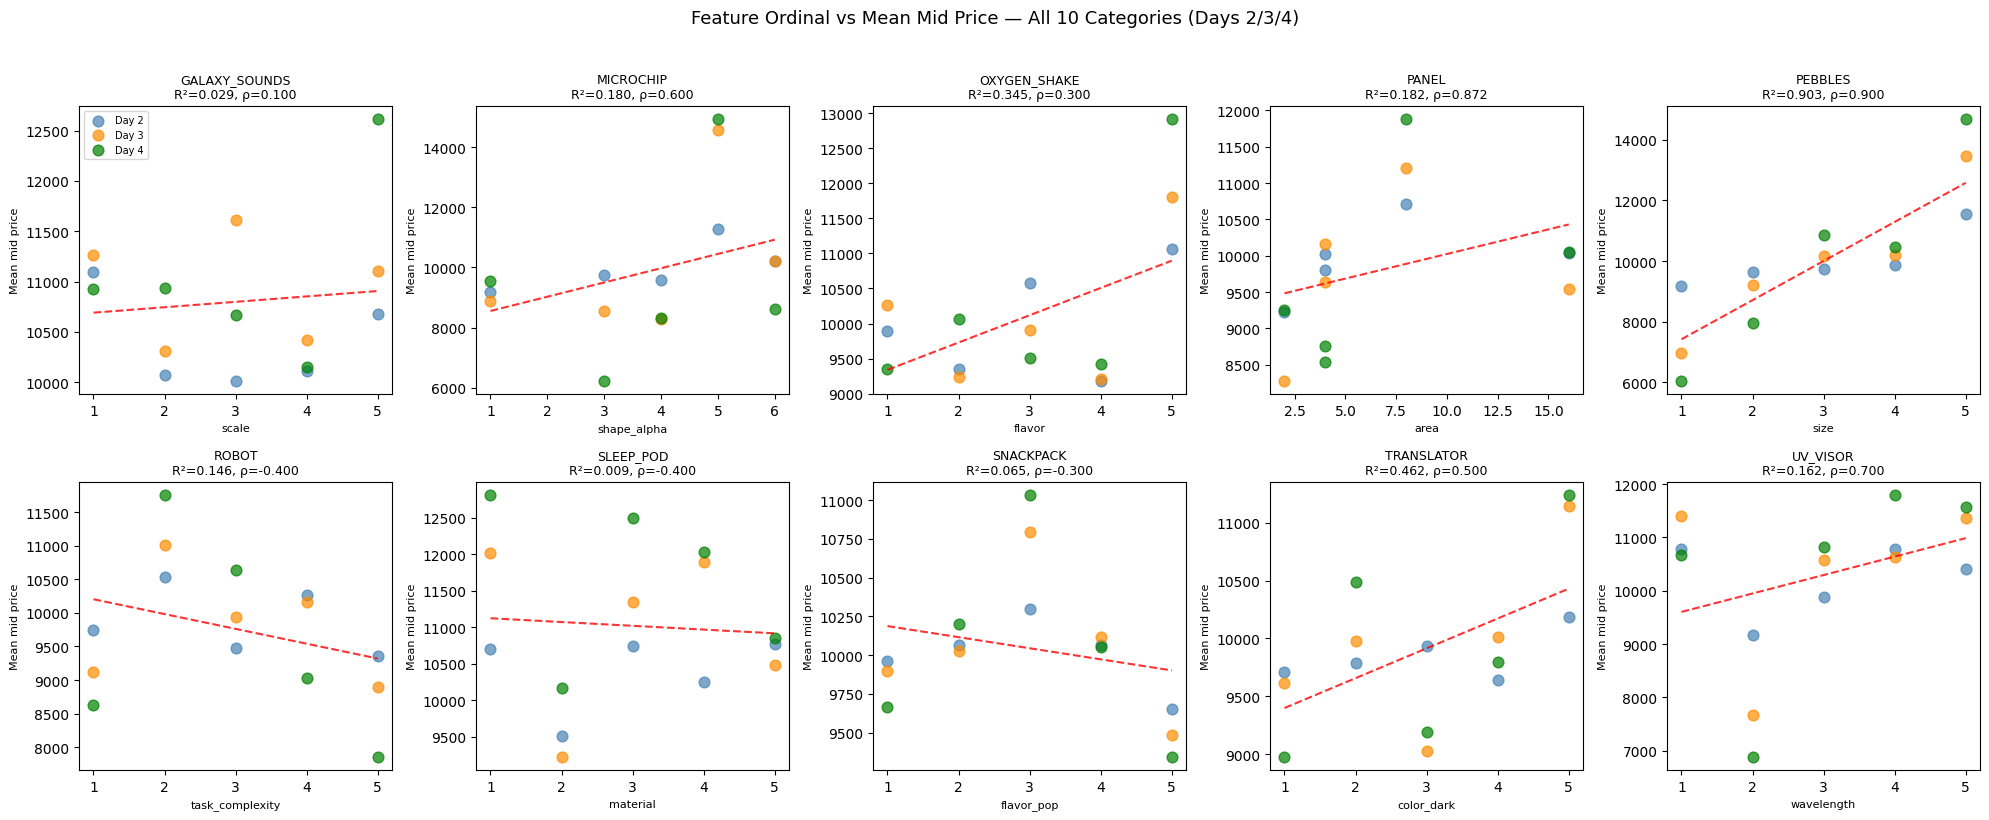

Plot saved.


In [12]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cats = sorted(per_product['category'].unique())

for i, cat in enumerate(cats):
    ax = axes[i]
    sub = per_product[per_product['category'] == cat].sort_values('feature_ordinal')
    
    # Day-by-day scatter
    colors = {2: 'steelblue', 3: 'darkorange', 4: 'green'}
    for d in days:
        d_sub = merged[(merged['category'] == cat) & (merged['day'] == d)].sort_values('feature_ordinal')
        ax.scatter(d_sub['feature_ordinal'], d_sub['mean_mid'], color=colors[d], alpha=0.7, s=60, label=f'Day {d}')
    
    # OLS line using 3-day average
    x = sub['feature_ordinal'].values.astype(float)
    y = sub['mean_mid_3day'].values.astype(float)
    if len(x) >= 2:
        sl, ic, rv, pv, _ = linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_line, sl*x_line + ic, 'r--', lw=1.5, alpha=0.8)
        ax.set_title(f'{cat}\nR²={rv**2:.3f}, ρ={spearmanr(x,y)[0]:.3f}', fontsize=9)
    
    ax.set_xlabel(sub['feature_name'].iloc[0], fontsize=8)
    ax.set_ylabel('Mean mid price', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('Feature Ordinal vs Mean Mid Price — All 10 Categories (Days 2/3/4)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/07_feature_vs_price.png', 
            dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Cell 13 — Cross-day stability: are price ranks consistent day to day?

In [13]:
# For each category, compute price rank of each product per day
# Then check if the rank ordering is consistent

print('Price rank consistency across days (Spearman ρ between day pairs):')
print(f'{"Category":<20} {"ρ(D2,D3)":>10} {"ρ(D2,D4)":>10} {"ρ(D3,D4)":>10} {"mean_ρ":>10}')
print('-' * 65)

rank_stability = []
for cat in sorted(merged['category'].dropna().unique()):
    pivoted = merged[merged['category']==cat].pivot(index='product', columns='day', values='mean_mid')
    if pivoted.shape[1] < 3:
        continue
    rho23, _ = spearmanr(pivoted[2].values, pivoted[3].values)
    rho24, _ = spearmanr(pivoted[2].values, pivoted[4].values)
    rho34, _ = spearmanr(pivoted[3].values, pivoted[4].values)
    mean_rho = np.mean([rho23, rho24, rho34])
    print(f'{cat:<20} {rho23:>10.4f} {rho24:>10.4f} {rho34:>10.4f} {mean_rho:>10.4f}')
    rank_stability.append({'category': cat, 'rho23': rho23, 'rho24': rho24, 'rho34': rho34, 'mean_rho': mean_rho})

stab_df = pd.DataFrame(rank_stability).sort_values('mean_rho', ascending=False)
print('\nStability ranking (mean Spearman ρ across day pairs):')
print(stab_df.round(4).to_string(index=False))

Price rank consistency across days (Spearman ρ between day pairs):
Category               ρ(D2,D3)   ρ(D2,D4)   ρ(D3,D4)     mean_ρ
-----------------------------------------------------------------
GALAXY_SOUNDS            0.0000     0.3000    -0.2000     0.0333
MICROCHIP                0.7000     0.3000     0.8000     0.6000
OXYGEN_SHAKE             0.9000     0.5000     0.3000     0.5667
PANEL                    0.6000     0.6000     0.2000     0.4667
PEBBLES                  1.0000     0.9000     0.9000     0.9333
ROBOT                    0.9000     0.7000     0.9000     0.8333
SLEEP_POD                0.1000     0.3000     0.9000     0.4333
SNACKPACK                1.0000     0.9000     0.9000     0.9333
TRANSLATOR               0.1000     0.5000     0.8000     0.4667
UV_VISOR                 0.9000     0.4000     0.3000     0.5333

Stability ranking (mean Spearman ρ across day pairs):
     category  rho23  rho24  rho34  mean_rho
      PEBBLES    1.0    0.9    0.9    0.9333
    SNA

## Cell 14 — Absolute price spread vs feature range

Even if feature doesn't predict price, there may still be a large absolute spread (max - min across products) within a category that is exploitable as a cross-sectional signal.

In [14]:
# Price spread per category (max - min across products)
spread_table = []
for cat in sorted(merged['category'].dropna().unique()):
    sub = per_product[per_product['category'] == cat]
    price_max = sub['mean_mid_3day'].max()
    price_min = sub['mean_mid_3day'].min()
    spread = price_max - price_min
    mean_p = sub['mean_mid_3day'].mean()
    rel_spread = spread / mean_p * 100
    spread_table.append({
        'category': cat, 
        'min_price': round(price_min, 2), 
        'max_price': round(price_max, 2),
        'abs_spread': round(spread, 2),
        'rel_spread_pct': round(rel_spread, 3),
        'mean_price': round(mean_p, 2)
    })

spread_df = pd.DataFrame(spread_table).sort_values('rel_spread_pct', ascending=False)
print('Intra-category price spread (products ranked by spread):')
print(spread_df.to_string(index=False))

Intra-category price spread (products ranked by spread):
     category  min_price  max_price  abs_spread  rel_spread_pct  mean_price
      PEBBLES    7404.64   13225.59     5820.95          58.210     9999.99
    MICROCHIP    8179.60   13594.75     5415.15          54.800     9881.61
     UV_VISOR    7911.70   11111.79     3200.10          31.087    10294.15
 OXYGEN_SHAKE    9271.89   11925.64     2653.74          26.226    10118.65
        ROBOT    8701.57   11100.21     2398.64          24.571     9761.93
        PANEL    8922.73   11265.37     2342.64          23.885     9808.20
    SLEEP_POD    9636.47   11840.56     2204.09          20.000    11020.70
   TRANSLATOR    9385.22   10858.58     1473.36          14.860     9914.82
    SNACKPACK    9495.84   10706.61     1210.76          12.054    10044.19
GALAXY_SOUNDS   10226.66   11466.87     1240.21          11.485    10798.06


## Cell 15 — Day-over-day price delta per product (are prices shifting?)

In [15]:
# Day-over-day price delta per product
pivot = mean_mid.pivot(index='product', columns='day', values='mean_mid')
pivot.columns.name = None
pivot['delta_3_2'] = pivot[3] - pivot[2]
pivot['delta_4_3'] = pivot[4] - pivot[3]
pivot['delta_4_2'] = pivot[4] - pivot[2]
pivot = pivot.reset_index()
pivot = pivot.merge(feat_df[['product', 'category']], on='product', how='left')

print('Day-over-day mean mid deltas (selected large movers):')
top_movers = pivot.reindex(pivot['delta_4_2'].abs().sort_values(ascending=False).index)
print(top_movers[['product', 'category', 2, 3, 4, 'delta_3_2', 'delta_4_3', 'delta_4_2']].head(20).round(2).to_string(index=False))

Day-over-day mean mid deltas (selected large movers):
                  product      category        2        3        4  delta_3_2  delta_4_3  delta_4_2
         MICROCHIP_SQUARE     MICROCHIP 11268.46 14584.24 14931.54    3315.78     347.30    3663.08
           MICROCHIP_OVAL     MICROCHIP  9766.38  8543.77  6228.64   -1222.61   -2315.13   -3537.74
               PEBBLES_XS       PEBBLES  9189.41  6968.41  6056.10   -2221.00    -912.31   -3133.30
               PEBBLES_XL       PEBBLES 11549.77 13462.10 14664.90    1912.33    1202.81    3115.14
           UV_VISOR_AMBER      UV_VISOR  9177.21  7672.90  6884.98   -1504.30    -787.92   -2292.22
      SLEEP_POD_POLYESTER     SLEEP_POD 10696.78 12015.36 12809.54    1318.57     794.19    2112.76
GALAXY_SOUNDS_BLACK_HOLES GALAXY_SOUNDS 10680.49 11107.88 12612.25     427.39    1504.37    1931.75
      OXYGEN_SHAKE_GARLIC  OXYGEN_SHAKE 11058.25 11807.84 12910.83     749.59    1102.99    1852.58
          SLEEP_POD_SUEDE     SLEEP_POD 10254.

## Cell 16 — Key findings summary table

In [16]:
# Merge regression results with rank stability
final_summary = summary.merge(stab_df[['category', 'mean_rho']], on='category', how='left')
final_summary = final_summary.rename(columns={'mean_rho': 'price_rank_stability'})

# Sort by: strong feature-price correlation AND stable rank
final_summary['combined_score'] = final_summary['mean_r2'] * 0.5 + abs(final_summary['mean_spearman']) * 0.5
final_summary = final_summary.sort_values('combined_score', ascending=False)

print('FINAL SUMMARY — Feature-to-price signal strength:')
print('(R² = OLS fit; Spearman = rank correlation; stability = day-to-day rank consistency)')
print()
cols = ['category', 'mean_r2', 'mean_spearman', 'price_rank_stability', 'rel_range_pct', 'mean_price']
print(final_summary[cols].round(4).to_string(index=False))

FINAL SUMMARY — Feature-to-price signal strength:
(R² = OLS fit; Spearman = rank correlation; stability = day-to-day rank consistency)

     category  mean_r2  mean_spearman  price_rank_stability  rel_range_pct  mean_price
      PEBBLES   0.8519         0.9667                0.9333          58.21   9999.9867
   TRANSLATOR   0.3876         0.6000                0.4667          16.60   9914.8200
    MICROCHIP   0.2760         0.5000                0.6000          57.59   9881.6133
        PANEL   0.1608         0.5985                0.4667          26.32   9808.2000
 OXYGEN_SHAKE   0.2817         0.3333                0.5667          26.46  10118.6533
        ROBOT   0.1154        -0.4000                0.8333          24.57   9761.9267
     UV_VISOR   0.1350         0.2333                0.5333          33.20  10294.1467
    SNACKPACK   0.0908        -0.1667                0.9333          12.05  10044.1867
GALAXY_SOUNDS   0.0888        -0.0333                0.0333          14.98  10798

## Cell 17 — SNACKPACK and OXYGEN_SHAKE flavor detail

In [17]:
for cat in ['SNACKPACK', 'OXYGEN_SHAKE']:
    sub = per_product[per_product['category'] == cat].sort_values('feature_ordinal')
    print(f'\n--- {cat} ---')
    print(sub[['product', 'feature_ordinal', 'mean_mid_3day']].to_string(index=False))
    
    day_sub = merged[merged['category'] == cat].sort_values(['day', 'feature_ordinal'])
    for d in days:
        s = day_sub[day_sub['day']==d]
        rho, p = spearmanr(s['feature_ordinal'], s['mean_mid'])
        sl, ic, rv, pv, _ = linregress(s['feature_ordinal'].values.astype(float), s['mean_mid'].values.astype(float))
        print(f'  Day {d}: Spearman ρ = {rho:.4f} (p={p:.4f}), R² = {rv**2:.4f}')


--- SNACKPACK ---
             product  feature_ordinal  mean_mid_3day
 SNACKPACK_CHOCOLATE                1    9843.371650
   SNACKPACK_VANILLA                2   10097.302467
SNACKPACK_STRAWBERRY                3   10706.608500
 SNACKPACK_RASPBERRY                4   10077.812067
 SNACKPACK_PISTACHIO                5    9495.843917
  Day 2: Spearman ρ = -0.1000 (p=0.8729), R² = 0.1729
  Day 3: Spearman ρ = -0.1000 (p=0.8729), R² = 0.0602
  Day 4: Spearman ρ = -0.3000 (p=0.6238), R² = 0.0392

--- OXYGEN_SHAKE ---
                    product  feature_ordinal  mean_mid_3day
          OXYGEN_SHAKE_MINT                1    9838.394083
     OXYGEN_SHAKE_CHOCOLATE                2    9556.879133
OXYGEN_SHAKE_MORNING_BREATH                3   10000.453350
OXYGEN_SHAKE_EVENING_BREATH                4    9271.895000
        OXYGEN_SHAKE_GARLIC                5   11925.639767
  Day 2: Spearman ρ = 0.3000 (p=0.6238), R² = 0.1826
  Day 3: Spearman ρ = 0.1000 (p=0.8729), R² = 0.2054
  Day 4: Spea

## Cell 18 — ROBOT and GALAXY_SOUNDS detail

In [18]:
for cat in ['ROBOT', 'GALAXY_SOUNDS', 'SLEEP_POD', 'TRANSLATOR']:
    sub = per_product[per_product['category'] == cat].sort_values('feature_ordinal')
    print(f'\n--- {cat} ---')
    print(sub[['product', 'feature_ordinal', 'mean_mid_3day']].to_string(index=False))
    
    day_sub = merged[merged['category'] == cat].sort_values(['day', 'feature_ordinal'])
    for d in days:
        s = day_sub[day_sub['day']==d]
        rho, p = spearmanr(s['feature_ordinal'], s['mean_mid'])
        sl, ic, rv, pv, _ = linregress(s['feature_ordinal'].values.astype(float), s['mean_mid'].values.astype(float))
        print(f'  Day {d}: Spearman ρ = {rho:.4f} (p={p:.4f}), R² = {rv**2:.4f}')


--- ROBOT ---
        product  feature_ordinal  mean_mid_3day
ROBOT_VACUUMING                1    9166.775783
  ROBOT_MOPPING                2   11100.213233
   ROBOT_DISHES                3   10018.314900
  ROBOT_LAUNDRY                4    9822.761700
  ROBOT_IRONING                5    8701.570267
  Day 2: Spearman ρ = -0.5000 (p=0.3910), R² = 0.1053
  Day 3: Spearman ρ = -0.3000 (p=0.6238), R² = 0.0594
  Day 4: Spearman ρ = -0.4000 (p=0.5046), R² = 0.1815

--- GALAXY_SOUNDS ---
                      product  feature_ordinal  mean_mid_3day
   GALAXY_SOUNDS_SOLAR_FLAMES                1   11092.571700
    GALAXY_SOUNDS_SOLAR_WINDS                2   10437.543967
GALAXY_SOUNDS_PLANETARY_RINGS                3   10766.673183
    GALAXY_SOUNDS_DARK_MATTER                4   10226.661817
    GALAXY_SOUNDS_BLACK_HOLES                5   11466.872083
  Day 2: Spearman ρ = -0.1000 (p=0.8729), R² = 0.0680
  Day 3: Spearman ρ = -0.1000 (p=0.8729), R² = 0.0029
  Day 4: Spearman ρ = 0.1000 (p=

## Cell 19 — High-R² follow-up: print exact product prices for strongest signal categories

In [19]:
# For the top-3 categories by mean_r2, print full day-by-day detail
top3 = final_summary.head(3)['category'].values
print('Top categories by feature-price correlation:')
for cat in top3:
    sub_d = merged[merged['category']==cat].sort_values(['day', 'feature_ordinal'])
    print(f'\n====== {cat} ======')
    print(sub_d[['day', 'product', 'feature_ordinal', 'mean_mid']].round(2).to_string(index=False))
    # What fraction of feature variance explains price variance?
    for d in days:
        s = sub_d[sub_d['day']==d]
        sl, ic, rv, pv, _ = linregress(s['feature_ordinal'].values.astype(float), s['mean_mid'].values.astype(float))
        rho, rp = spearmanr(s['feature_ordinal'].values, s['mean_mid'].values)
        print(f'  Day {d}: slope={sl:.2f} per unit, R²={rv**2:.4f}, p={pv:.4f}, Spearman ρ={rho:.4f}')

Top categories by feature-price correlation:

====== PEBBLES ======
 day    product  feature_ordinal  mean_mid
   2 PEBBLES_XS                1   9189.41
   2  PEBBLES_S                2   9650.48
   2  PEBBLES_M                3   9747.45
   2  PEBBLES_L                4   9862.81
   2 PEBBLES_XL                5  11549.77
   3 PEBBLES_XS                1   6968.41
   3  PEBBLES_S                2   9197.52
   3  PEBBLES_M                3  10170.49
   3  PEBBLES_L                4  10201.45
   3 PEBBLES_XL                5  13462.10
   4 PEBBLES_XS                1   6056.10
   4  PEBBLES_S                2   7949.07
   4  PEBBLES_M                3  10871.79
   4  PEBBLES_L                4  10458.07
   4 PEBBLES_XL                5  14664.90
  Day 2: slope=493.31 per unit, R²=0.7456, p=0.0593, Spearman ρ=1.0000
  Day 3: slope=1399.13 per unit, R²=0.8943, p=0.0151, Spearman ρ=1.0000
  Day 4: slope=1972.66 per unit, R²=0.9158, p=0.0106, Spearman ρ=0.9000

====== TRANSLATOR ======
 da